In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# อ่านไฟล์ CSV โดยใช้ comma เป็นตัวคั่น (รองรับกรณีมีช่องว่างรอบ ๆ ,)
data = pd.read_csv("HouseSale.csv", sep=r"\s*,\s*", engine="python")

# ถ้ามีคอลัมน์เกินมา ให้เลือกเฉพาะ 6 คอลัมน์แรก
if data.shape[1] > 6:
    data = data.iloc[:, :6]

# ตั้งชื่อคอลัมน์ใหม่
data.columns = [
    "area",
    "bedrooms",
    "bathrooms",
    "age",
    "zone_rating",
    "price"
]

# แปลงข้อมูลทุกคอลัมน์ให้เป็นตัวเลข
# ถ้าแปลงไม่ได้ (เช่น ตัวอักษรหรือช่องว่าง) จะถูกแทนด้วย NaN
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna()

X = data[["area", "bedrooms", "bathrooms", "age", "zone_rating"]]
y = data["price"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # สัดส่วนข้อมูลที่ใช้เป็นชุดทดสอบ (20%)
    random_state=42,      # กำหนดค่า seed เพื่อให้แบ่งข้อมูลเหมือนเดิมทุกครั้ง
    shuffle=True          # สุ่มข้อมูลก่อนแบ่ง train / test
)

scaler = StandardScaler() # ใช้ทำ normalization แบบ Z-score (mean=0, std=1)

X_train_scaled = scaler.fit_transform(X_train)  # คำนวณค่า mean/std จาก train แล้ว normalize
X_test_scaled = scaler.transform(X_test)        # normalize test ด้วยค่าเดียวกับ train

model = Ridge(
    alpha=1.0,            # ความแรงของ L2 regularization (ยิ่งมาก → coef ยิ่งถูกลดขนาด)
    fit_intercept=True,   # ให้โมเดลเรียนค่า intercept (β0)
    copy_X=True,          # คัดลอกข้อมูล X เพื่อไม่แก้ไขข้อมูลต้นฉบับ
    max_iter=None,        # ใช้ค่า iteration เริ่มต้นของ solver
    tol=0.0001,           # ค่า tolerance สำหรับเงื่อนไขหยุดการคำนวณ
    solver="auto",        # ให้ sklearn เลือก solver ที่เหมาะสมให้อัตโนมัติ
    random_state=42       # ควบคุมความสุ่มของบาง solver (เพื่อให้ผลซ้ำได้)
)


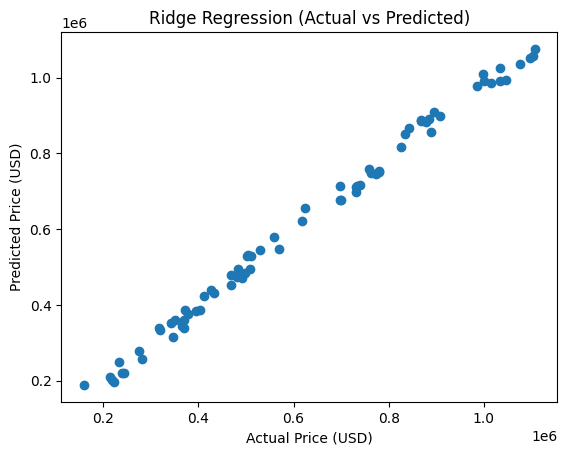

In [7]:
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Ridge Regression (Actual vs Predicted)")
plt.show()

In [8]:
mse = mean_squared_error(y_test, y_pred_test)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("Model: Lasso Regression")
print(f"MSE  : {mse:.2e}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R^2  : {r2:.4f}")

Model: Lasso Regression
MSE  : 4.80e+08
RMSE : 21913.15
MAE  : 18966.83
R^2  : 0.9935
